# Dataset Information
This dataset is constructed from the following sources:
* FewRel: A Large-Scale Supervised Few-Shot Relation Classification Dataset with State-of-the-Art Evaluation. https://arxiv.org/abs/1808.07001
* Wiki_TekGen from Text2Bench : A Benchmark for Evaluating Text Generation in Knowledge-Intensive Tasks. https://arxiv.org/abs/2210.16144
* The inverse relation pairs are considered from these two resources.
## License
CC BY-SA 4.0 License on Zenodo

## Citation



## Dataset Overview


In [12]:
import os
import sys
import json
import matplotlib.pyplot as plt
import pandas as pd


In [13]:


def read_json_file(file_path):
    """
    Reads a JSON file and returns its content.
    
    Args:
        file_path (str): The path to the JSON file.
        
    Returns:
        dict: The content of the JSON file.
    """

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")
    
    with open(file_path, 'r') as file:
        return json.load(file)
    
def write_json_file(data, file_path):
    """
    Writes data to a JSON file.
    
    Args:
        data (dict): The data to be written to the file.
        file_path (str): The path to the JSON file.
    """
    if os.path.exists(file_path):
        print(f"Warning: The file {file_path} already exists and will be overwritten.", file=sys.stderr)
    
    with open(file_path, 'w') as file:
        json.dump(data, file, indent=4)


def write_json_str(data, file_path):
    """
    Writes data to a JSON file, converting non-serializable types (like sets).

    Args:
        data (dict): The data to be written to the file.
        file_path (str): The path to the JSON file.
    """
    def convert(obj):
        if isinstance(obj, set):
            return list(obj)
        raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

    if os.path.exists(file_path):
        print(f"Warning: The file {file_path} already exists and will be overwritten.", file=sys.stderr)
    
    json_str = json.dumps(data, indent=4, default=convert)
    
    with open(file_path, 'w') as file:
        file.write(json_str)
        
def write_turtle_to_ttl(file_path, content):
    """
    Writes Turtle content to a TTL file.
    
    Args:
        file_path (str): The path to the TTL file.
        content (str): The Turtle content to be written.
    """
    content = "\n".join(content)  # Ensure content is a single string
    content = content.replace(' .', '.')
    content = content.replace(' ;', ';')

    with open(file_path, 'w') as file:
        file.write(content)

In [4]:
def load_json(path):
    pass
def barchart(data, title, xlabel, ylabel):
    pass


## Dataset Statistics

This section compares the source FewRel and TekGen datasets by total sample count and by the number of samples per relation.


,dataset,total_samples,unique_relations
0,FewRel,3401,7
1,TekGen,3460,24


,scope,total_samples,unique_relations
0,Both datasets combined,6861,27


,relation,samples,dataset
0,child,988,FewRel
1,father,571,FewRel
2,mother,515,FewRel
3,followed by,508,FewRel
4,follows,493,FewRel
5,has part,174,FewRel
6,part of,152,FewRel
7,characters,284,TekGen
8,present in work,284,TekGen
9,position held,160,TekGen


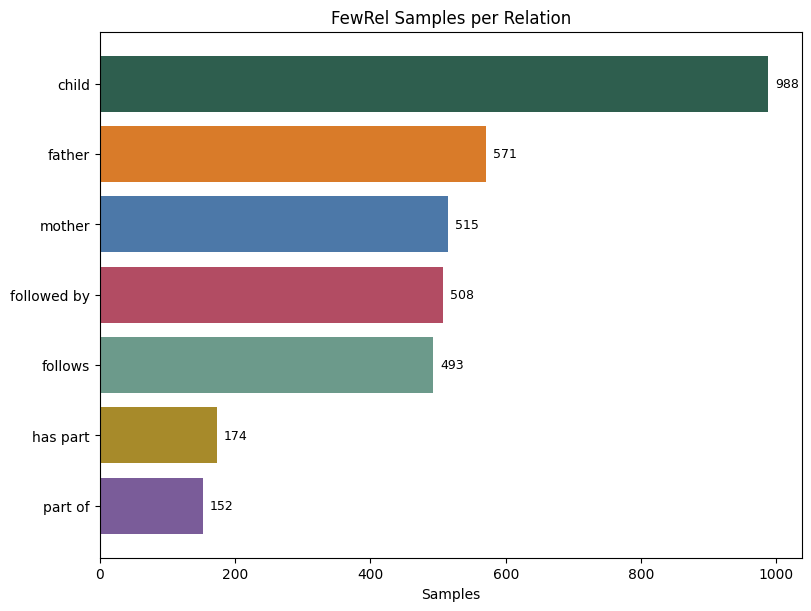

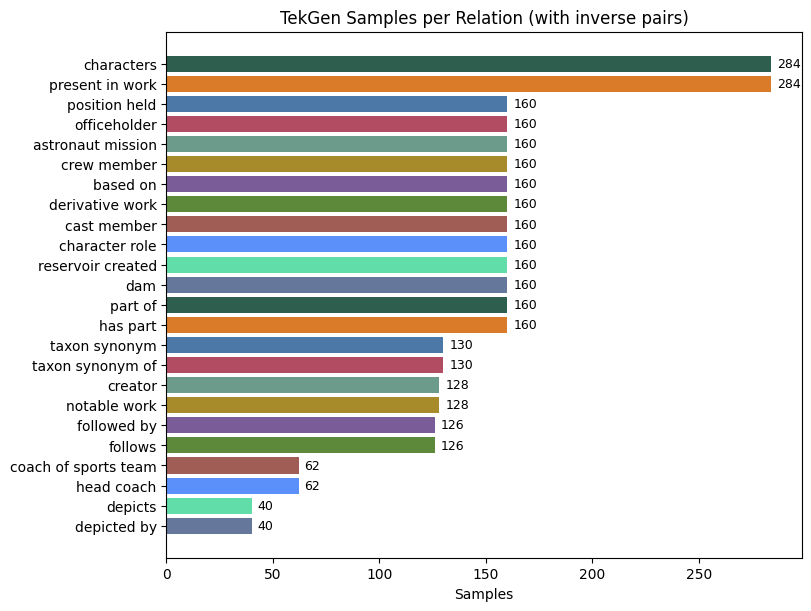

Saved: ../figure/fewrel_samples_per_relation.png
Saved: ../figure/fewrel_samples_per_relation.pdf
Saved: ../figure/tekgen_samples_per_relation_inverse_pairs.png
Saved: ../figure/tekgen_samples_per_relation_inverse_pairs.pdf
Does TekGen include 'follows'? True
TekGen 'follows' count: 126
Total unique relations across both datasets: 27


In [ ]:
from collections import Counter
from pathlib import Path

root = Path('..')
figure_dir = root / 'figure'
figure_dir.mkdir(parents=True, exist_ok=True)

fewrel_path = root / 'data' / 'ablation-tekgen' / 'original_fewrel_inverse.json'
tekgen_path = root / 'data' / 'ablation-tekgen' / 'original_tekgen_inverse.json'
fewrel_rel_path = root / 'data' / 'mqa' / 'fewrel' / 'pid2name_fewrel.json'

fewrel = read_json_file(fewrel_path)
tekgen = read_json_file(tekgen_path)
fewrel_rel = {item['pid']: item['name'] for item in read_json_file(fewrel_rel_path)}

fewrel_counts = Counter(fewrel_rel.get(item['head_to_tail'], item['head_to_tail']) for item in fewrel)

# Count both original and inverse TekGen relations.
tekgen_relation_labels = []
for item in tekgen:
    if item.get('head_to_tail'):
        tekgen_relation_labels.append(item['head_to_tail'])
    if item.get('tail_to_head'):
        tekgen_relation_labels.append(item['tail_to_head'])
tekgen_counts = Counter(tekgen_relation_labels)

fewrel_df = pd.DataFrame(fewrel_counts.most_common(), columns=['relation', 'samples'])
fewrel_df['dataset'] = 'FewRel'
tekgen_df = pd.DataFrame(tekgen_counts.most_common(), columns=['relation', 'samples'])
tekgen_df['dataset'] = 'TekGen'
stats_df = pd.concat([fewrel_df, tekgen_df], ignore_index=True)

summary_df = pd.DataFrame([
    {'dataset': 'FewRel', 'total_samples': len(fewrel), 'unique_relations': len(fewrel_counts)},
    {'dataset': 'TekGen', 'total_samples': len(tekgen_relation_labels), 'unique_relations': len(tekgen_counts)}
])

display(summary_df)
display(stats_df)

palette = ['#2E5E4E', '#D97B29', '#4C78A8', '#B24C63', '#6C9A8B', '#A78A2A', '#7A5C99', '#5C8A3A', '#A05D56', '#5B8FF9', '#61DDAA', '#65789B']

# Separate chart for FewRel
fig_fewrel, ax_fewrel = plt.subplots(figsize=(8, 6), constrained_layout=True)
fewrel_labels = [label for label, _ in fewrel_counts.most_common()]
fewrel_values = [value for _, value in fewrel_counts.most_common()]
fewrel_bars = ax_fewrel.barh(
    fewrel_labels,
    fewrel_values,
    color=palette[:len(fewrel_labels)]
)
ax_fewrel.invert_yaxis()
ax_fewrel.set_title('FewRel Samples per Relation')
ax_fewrel.set_xlabel('Samples')
for bar, value in zip(fewrel_bars, fewrel_values):
    ax_fewrel.text(
        value + max(fewrel_values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va='center',
        fontsize=9,
    )
fewrel_png_path = figure_dir / 'fewrel_samples_per_relation.png'
fewrel_pdf_path = figure_dir / 'fewrel_samples_per_relation.pdf'
fig_fewrel.savefig(fewrel_png_path, dpi=300, bbox_inches='tight')
fig_fewrel.savefig(fewrel_pdf_path, bbox_inches='tight')
plt.show()

# Separate chart for TekGen (including inverse pairs)
fig_tekgen, ax_tekgen = plt.subplots(figsize=(8, 6), constrained_layout=True)
tekgen_labels = [label for label, _ in tekgen_counts.most_common()]
tekgen_values = [value for _, value in tekgen_counts.most_common()]
tekgen_bars = ax_tekgen.barh(
    tekgen_labels,
    tekgen_values,
    color=palette[:len(tekgen_labels)]
)
ax_tekgen.invert_yaxis()
ax_tekgen.set_title('TekGen Samples per Relation (with inverse pairs)')
ax_tekgen.set_xlabel('Samples')
for bar, value in zip(tekgen_bars, tekgen_values):
    ax_tekgen.text(
        value + max(tekgen_values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va='center',
        fontsize=9,
    )
tekgen_png_path = figure_dir / 'tekgen_samples_per_relation_inverse_pairs.png'
tekgen_pdf_path = figure_dir / 'tekgen_samples_per_relation_inverse_pairs.pdf'
fig_tekgen.savefig(tekgen_png_path, dpi=300, bbox_inches='tight')
fig_tekgen.savefig(tekgen_pdf_path, bbox_inches='tight')
plt.show()

print('Saved:', fewrel_png_path)
print('Saved:', fewrel_pdf_path)
print('Saved:', tekgen_png_path)
print('Saved:', tekgen_pdf_path)
print("Does TekGen include 'follows'?", 'follows' in tekgen_counts)
if 'follows' in tekgen_counts:
    print("TekGen 'follows' count:", tekgen_counts['follows'])


In [25]:
# Additional statistics in pandas view
fewrel_total_samples = len(fewrel)
fewrel_unique_relations = len(fewrel_counts)
tekgen_total_samples = len(tekgen_relation_labels)
tekgen_unique_relations = len(tekgen_counts)

fewrel_values = pd.Series(list(fewrel_counts.values()))
tekgen_values = pd.Series(list(tekgen_counts.values()))

combined_counts = fewrel_counts + tekgen_counts
combined_total_samples = int(fewrel_values.sum() + tekgen_values.sum())
combined_unique_relations = len(combined_counts)
combined_values = pd.Series(list(combined_counts.values()))

# Per-dataset statistics table
dataset_stats_df = pd.DataFrame([
    {
        'dataset': 'FewRel',
        'total_samples': fewrel_total_samples,
        'unique_relations': fewrel_unique_relations,
        'avg_samples_per_relation': round(fewrel_values.mean(), 2),
        'median_samples_per_relation': round(fewrel_values.median(), 2),
        'min_samples_per_relation': int(fewrel_values.min()),
        'max_samples_per_relation': int(fewrel_values.max()),
        'std_samples_per_relation': round(fewrel_values.std(ddof=0), 2),
        'top_relation': max(fewrel_counts, key=fewrel_counts.get),
        'top_relation_count': int(max(fewrel_counts.values())),
    },
    {
        'dataset': 'TekGen (with inverse)',
        'total_samples': tekgen_total_samples,
        'unique_relations': tekgen_unique_relations,
        'avg_samples_per_relation': round(tekgen_values.mean(), 2),
        'median_samples_per_relation': round(tekgen_values.median(), 2),
        'min_samples_per_relation': int(tekgen_values.min()),
        'max_samples_per_relation': int(tekgen_values.max()),
        'std_samples_per_relation': round(tekgen_values.std(ddof=0), 2),
        'top_relation': max(tekgen_counts, key=tekgen_counts.get),
        'top_relation_count': int(max(tekgen_counts.values())),
    },
    {
        'dataset': 'Combined',
        'total_samples': combined_total_samples,
        'unique_relations': combined_unique_relations,
        'avg_samples_per_relation': round(combined_values.mean(), 2),
        'median_samples_per_relation': round(combined_values.median(), 2),
        'min_samples_per_relation': int(combined_values.min()),
        'max_samples_per_relation': int(combined_values.max()),
        'std_samples_per_relation': round(combined_values.std(ddof=0), 2),
        'top_relation': max(combined_counts, key=combined_counts.get),
        'top_relation_count': int(max(combined_counts.values())),
    },
])

# Relation overlap statistics
fewrel_rel_set = set(fewrel_counts.keys())
tekgen_rel_set = set(tekgen_counts.keys())
shared_relations = sorted(fewrel_rel_set & tekgen_rel_set)
only_fewrel = sorted(fewrel_rel_set - tekgen_rel_set)
only_tekgen = sorted(tekgen_rel_set - fewrel_rel_set)
jaccard = len(shared_relations) / len(fewrel_rel_set | tekgen_rel_set)

overlap_stats_df = pd.DataFrame([
    {
        'shared_relations_count': len(shared_relations),
        'shared_relations': ', '.join(shared_relations),
        'fewrel_only_relations_count': len(only_fewrel),
        'fewrel_only_relations': ', '.join(only_fewrel),
        'tekgen_only_relations_count': len(only_tekgen),
        'tekgen_only_relations': ', '.join(only_tekgen),
        'jaccard_similarity': round(jaccard, 4),
    }
])

display(dataset_stats_df)
display(overlap_stats_df)

,dataset,total_samples,unique_relations,avg_samples_per_relation,median_samples_per_relation,min_samples_per_relation,max_samples_per_relation,std_samples_per_relation,top_relation,top_relation_count
0,FewRel,3401,7,485.86,508.0,152,988,258.98,child,988
1,TekGen (with inverse),3460,24,144.17,160.0,40,284,57.34,characters,284
2,Combined,6861,27,254.11,160.0,40,988,220.50,child,988


,shared_relations_count,shared_relations,fewrel_only_relations_count,fewrel_only_relations,tekgen_only_relations_count,tekgen_only_relations,jaccard_similarity
0,4,"followed by, follows, has part, part of",3,"child, father, mother",20,"astronaut mission, based on, cast member, char...",0.1481


### FewRel


In [19]:
def fewrel_formatting(data):
    new_data = []
    for item in data:
        new_item = {
            "head_to_tail": item["possible_probs"][0],
            "tail_to_head": item["possible_probs"][1],
            "tokens": item["tokens"],
            "tail": item["t"],
            "head": item["h"],
            "relation_prop_wiki": item["relation_prop_wiki"]
        }
        new_data.append(new_item)
    return new_data
def fewrel_artificial_formatting(data):
    new_data = []
    for item in data:
        new_item = {
            "head_to_tail": item["possible_probs"][0],
            "tail_to_head": item["possible_probs"][1],
            "tokens": item["tokens"],
            "tail": item["t"],
            "head": item["h"],
            "relation_prop_wiki": item["relation_prop_wiki"],
            "artificial_data": item["artificial_data"]
        }
        new_data.append(new_item)
    return new_data

In [ ]:
path = "../data/fewrel/cleaned_asymetrics_data.json"
artificial_path = "../data/fewrel/artificial_data.json"

fewrel_data = read_json_file(path)
artificial_fewrel_data = read_json_file(artificial_path)

formatted_fewrel_data = fewrel_formatting(fewrel_data)
formatted_artificial_fewrel_data = fewrel_artificial_formatting(artificial_fewrel_data)

fewrel_formatted_data_paths = {
    "original": "../data/fewrel/zenodo/original_fewrel_inverse.json",
    "artificial": "../data/fewrel/zenodo/artificial_fewrel_inverse.json"
}
write_json_file(formatted_fewrel_data, fewrel_formatted_data_paths["original"])
write_json_file(formatted_artificial_fewrel_data, fewrel_formatted_data_paths["artificial"])


### Wiki_TekGen

In [25]:

def tekgen_formatting(data):
    new_data = []
    for item in data:
        if item['rel_label'] in ['director', 'screenwriter']:
            continue
        new_item = {
            "id": item["id"],
            "head_to_tail": item["rel_label"],
            "tail_to_head": item["inverse_rel_label"],
            "tokens": item["sent"],
            "tail": item["sub_label"],
            "head": item["obj_label"],
        }
        new_data.append(new_item)
    return new_data

def tekgen_artificial_formatting(data):
    new_data = []
    for item in data:
        if item['rel_label'] in ['director', 'screenwriter', 'candidancy in election', 'next higher rank']:
            continue
        new_item = {
            "id": item["id"],
            "head_to_tail": item["rel_label"],
            "tail_to_head": item["inverse_rel_label"],
            "tokens": item["sent"],
            "tail": item["sub_label"],
            "head": item["obj_label"],
            "artificial_data": item["artificial_data"]
        }
        new_data.append(new_item)
    return new_data

In [ ]:
path = "../data/tekgen/tekgen_inverse.json"
artificial_path = "../data/tekgen/tekgen_inverse_artificial.json"

tekgen_data = read_json_file(path)
artificial_tekgen_data = read_json_file(artificial_path)

formatted_tekgen_data = tekgen_formatting(tekgen_data)
formatted_artificial_tekgen_data = tekgen_artificial_formatting(artificial_tekgen_data)
tekgen_formatted_data_paths = {
    "original": "../zenodo/original_tekgen_inverse.json",
    "artificial": "../zenodo/artificial_tekgen_inverse.json"
}
write_json_file(formatted_tekgen_data, tekgen_formatted_data_paths["original"])
write_json_file(formatted_artificial_tekgen_data, tekgen_formatted_data_paths["artificial"])